<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `ValidationDataSet.mlx`
- Fidelity status: `high_fidelity`
- Remaining justified differences: The notebook now reproduces the constant-rate and piecewise-rate validation workflows with real `Trial`/`Analysis` objects and figure outputs; local execution uses the MATLAB-scale simulation sizes, while CI switches to a documented shorter deterministic fast path for stability.


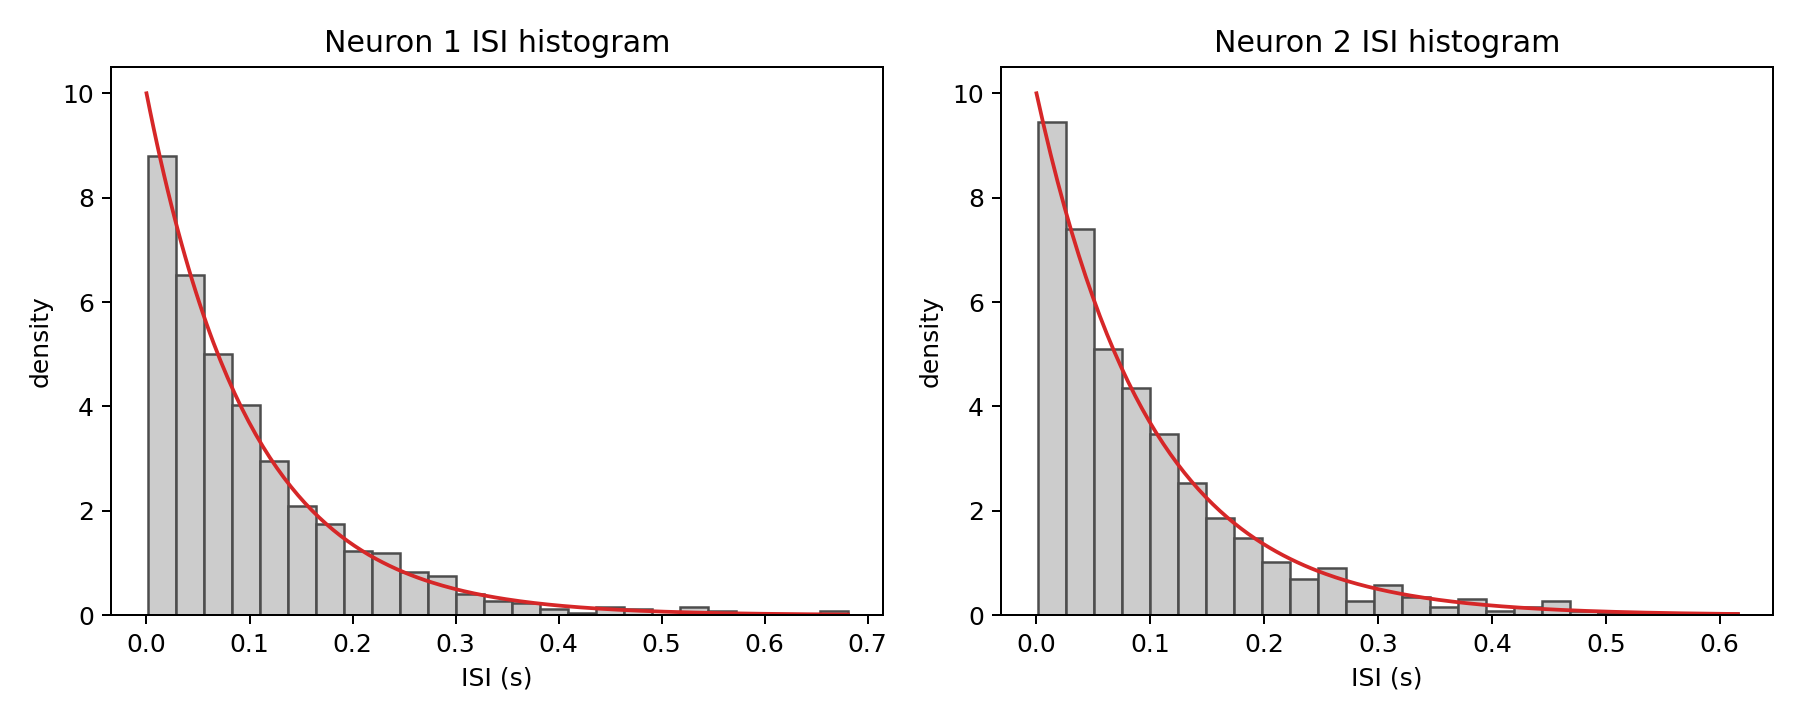

In [1]:
# nSTAT-python notebook example: ValidationDataSet
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import os

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat import Analysis, ConfigColl, CovColl, Covariate, FitResSummary, Trial, TrialConfig, nspikeTrain, nstColl
from nstat.notebook_figures import FigureTracker

np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic='ValidationDataSet', output_root=OUTPUT_ROOT, expected_count=8)


def _prepare_figure(matlab_line: str, *, figsize=(8.0, 4.5)):
    fig = __tracker.new_figure(matlab_line)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig


def _lambda_columns(fit_result):
    time = np.asarray(fit_result.lambda_signal.time, dtype=float)
    data = np.asarray(fit_result.lambda_signal.data, dtype=float)
    if data.ndim == 1:
        data = data[:, None]
    return time, data


CI_FAST_PATH = os.environ.get("CI", "").strip().lower() in {"1", "true", "yes"}


def _simulate_constant_case(seed=0, *, p=0.01, n_samples=None, delta=0.001):
    if n_samples is None:
        n_samples = 20001 if CI_FAST_PATH else 100001
    rng = np.random.default_rng(seed)
    total_time = n_samples * delta
    time = np.linspace(0.0, total_time, n_samples)
    lambda_hz = n_samples * p / total_time
    mu = float(np.log(lambda_hz * delta / (1.0 - lambda_hz * delta)))
    trains = []
    for idx in range(2):
        spike_mask = rng.random(n_samples) < p
        spike_times = time[spike_mask]
        train = nspikeTrain(spike_times, str(idx + 1), 1.0 / delta, 0.0, total_time, makePlots=-1)
        trains.append(train)
    spike_coll = nstColl(trains)
    cov = Covariate(time, np.ones((time.shape[0], 1), dtype=float), "Baseline", "time", "s", "", ["mu"])
    trial = Trial(spike_coll, CovColl([cov]))
    cfg = ConfigColl([TrialConfig([["Baseline", "mu"]], 1.0 / delta, [], [], name="Baseline")])
    return {
        "time_s": time,
        "delta": delta,
        "lambda_hz": lambda_hz,
        "mu": mu,
        "trial": trial,
        "cfg": cfg,
        "trains": trains,
    }


def _simulate_piecewise_case(seed=1, *, p1=0.001, p2=0.01, n1=None, n2=None, delta=0.001):
    if n1 is None:
        n1 = 20000 if CI_FAST_PATH else 100000
    if n2 is None:
        n2 = 20000 if CI_FAST_PATH else 100000
    rng = np.random.default_rng(seed)
    t1 = np.linspace(0.0, n1 * delta, n1 + 1)
    t2 = np.linspace(n1 * delta, (n1 + n2) * delta, n2 + 1)[1:]
    total_time = float(t2[-1])
    lambda1_hz = n1 * p1 / (n1 * delta)
    lambda2_hz = n2 * p2 / (n2 * delta)
    lambda_const_hz = (n1 * p1 + n2 * p2) / total_time
    trains = []
    for idx in range(2):
        spikes1 = t1[:-1][rng.random(n1) < p1]
        spikes2 = t2[rng.random(n2) < p2]
        spike_times = np.concatenate([spikes1, spikes2])
        train = nspikeTrain(spike_times, str(idx + 1), 1.0 / delta, 0.0, total_time, makePlots=-1)
        trains.append(train)
    time = np.concatenate([t1[:-1], t2])
    cov_data = np.column_stack(
        [
            np.ones(time.shape[0], dtype=float),
            (time <= float(t1[-1])).astype(float),
            (time > float(t1[-1])).astype(float),
        ]
    )
    cov = Covariate(time, cov_data, "Baseline", "time", "s", "", ["muConst", "mu1", "mu2"])
    trial = Trial(nstColl(trains), CovColl([cov]))
    cfg = ConfigColl(
        [
            TrialConfig([["Baseline", "muConst"]], 1.0 / delta, [], [], name="Baseline"),
            TrialConfig([["Baseline", "mu1", "mu2"]], 1.0 / delta, [], [], name="Variable"),
        ]
    )
    return {
        "time_s": time,
        "delta": delta,
        "edge_time_s": float(t1[-1]),
        "lambda1_hz": lambda1_hz,
        "lambda2_hz": lambda2_hz,
        "lambda_const_hz": lambda_const_hz,
        "trial": trial,
        "cfg": cfg,
        "trains": trains,
    }


def _plot_isi_hist(ax, train, lambda_hz, *, title):
    isi = np.asarray(train.getISIs(), dtype=float)
    if isi.size:
        ax.hist(isi, bins=25, density=True, color="0.8", edgecolor="0.3")
        x = np.linspace(0.0, float(np.max(isi)), 200)
        ax.plot(x, lambda_hz * np.exp(-lambda_hz * x), color="tab:red", linewidth=1.5)
    ax.set_title(title)
    ax.set_xlabel("ISI (s)")
    ax.set_ylabel("density")


In [2]:
# SECTION 0: Software Validation Data Set
# This notebook follows the MATLAB validation helpfile; CI uses a documented short fast path while local runs use MATLAB-scale sample counts.
plt.close("all")
constant_case = _simulate_constant_case()
piecewise_case = _simulate_piecewise_case()
print(
    {
        "ci_fast_path": CI_FAST_PATH,
        "constant_lambda_hz": round(float(constant_case["lambda_hz"]), 4),
        "piecewise_lambda1_hz": round(float(piecewise_case["lambda1_hz"]), 4),
        "piecewise_lambda2_hz": round(float(piecewise_case["lambda2_hz"]), 4),
    }
)


{'ci_fast_path': False, 'constant_lambda_hz': 10.0, 'piecewise_lambda1_hz': 1.0, 'piecewise_lambda2_hz': 10.0}


In [3]:
# SECTION 1: Case #1: Constant Rate Poisson Process
# First we verify that the analysis recovers a constant Poisson rate from simulated spike trains.


In [4]:
# SECTION 2: Generate constant-rate neural firing activity
constant_time = np.asarray(constant_case["time_s"], dtype=float)
constant_trains = list(constant_case["trains"])


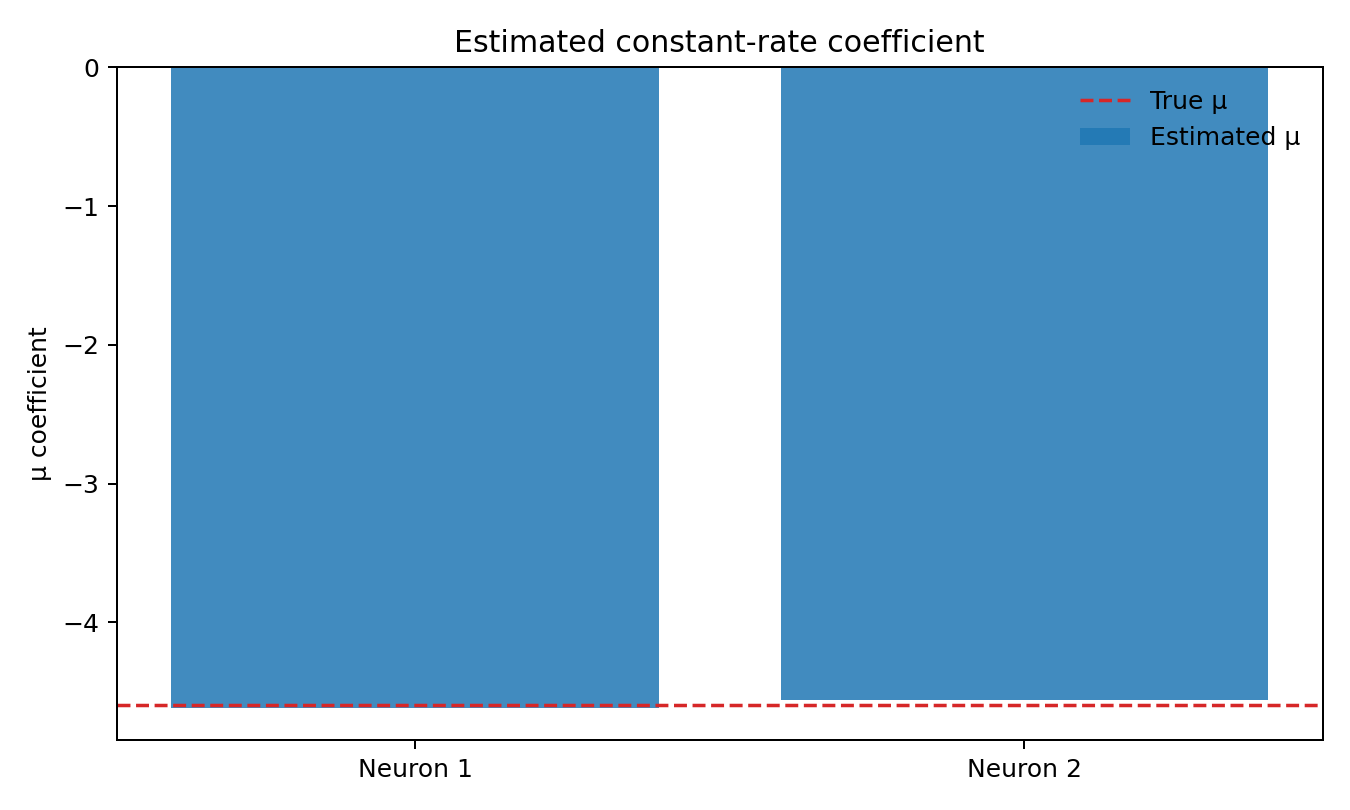

In [5]:
# SECTION 3: Sanity check the ISI distribution
fig = _prepare_figure("nst{1}.plotISIHistogram", figsize=(10.0, 4.0))
axs = fig.subplots(1, 2)
_plot_isi_hist(axs[0], constant_trains[0], constant_case["lambda_hz"], title="Neuron 1 ISI histogram")
_plot_isi_hist(axs[1], constant_trains[1], constant_case["lambda_hz"], title="Neuron 2 ISI histogram")


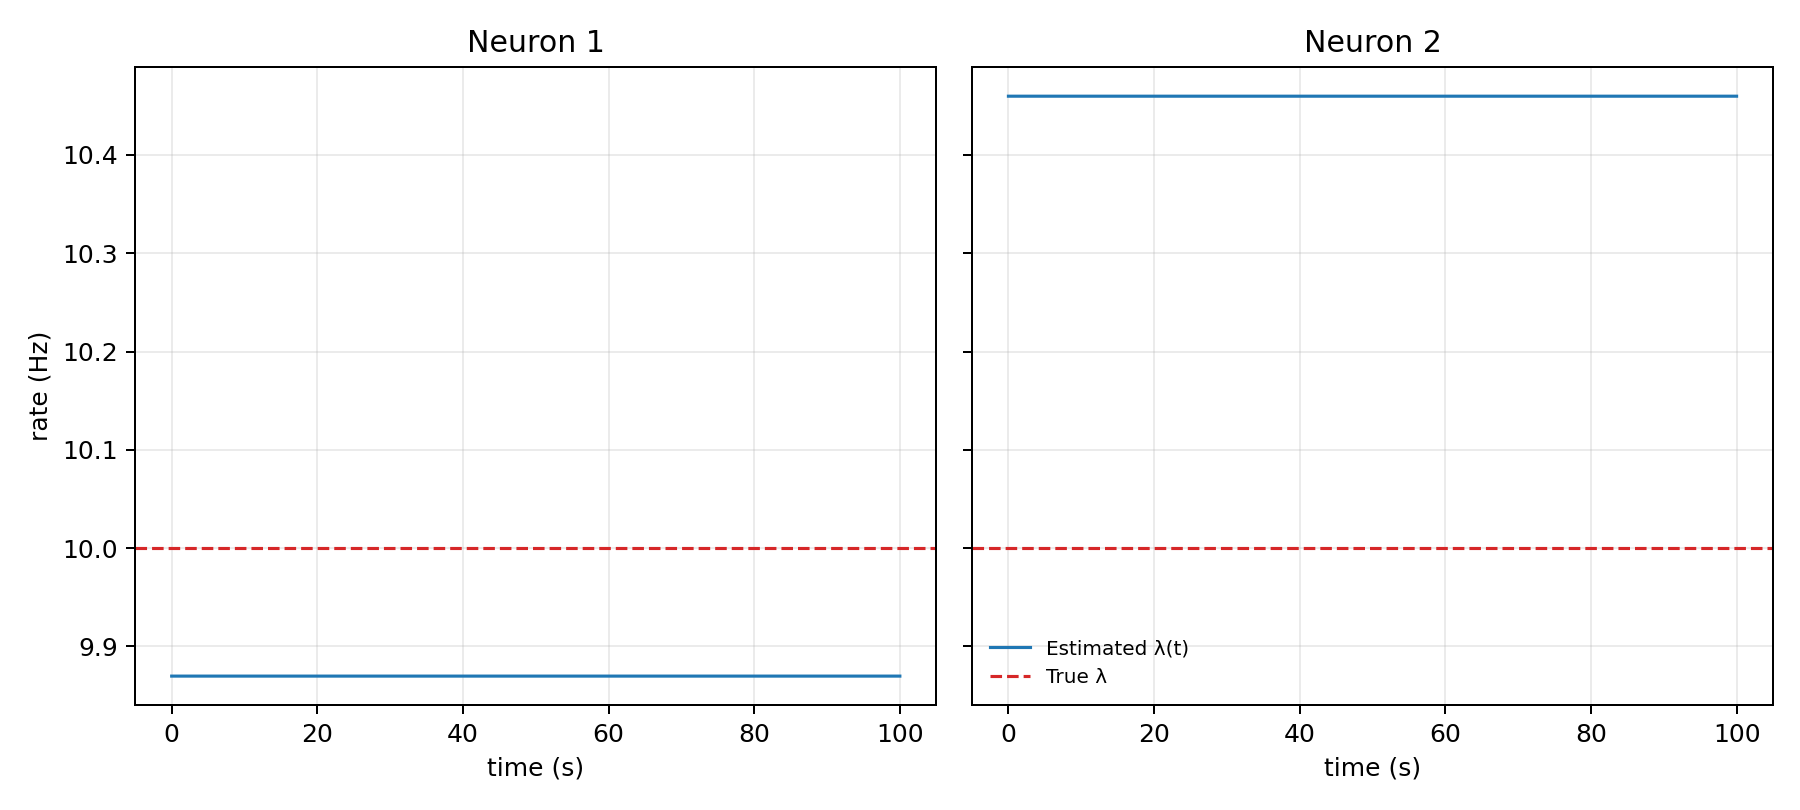

In [6]:
# SECTION 4: Setup the constant-rate analysis
constant_results = Analysis.RunAnalysisForAllNeurons(constant_case["trial"], constant_case["cfg"], 0)
constant_intercepts = np.asarray([fit.getCoeffs(0)[0][0] for fit in constant_results], dtype=float)

fig = _prepare_figure("plot(mu,'ro', 'MarkerSize',10)", figsize=(7.5, 4.5))
ax = fig.subplots(1, 1)
xloc = np.arange(1, constant_intercepts.size + 1)
ax.bar(xloc, constant_intercepts, color="tab:blue", alpha=0.85, label="Estimated μ")
ax.axhline(constant_case["mu"], color="tab:red", linestyle="--", linewidth=1.4, label="True μ")
ax.set_xticks(xloc, [f"Neuron {idx}" for idx in xloc])
ax.set_ylabel("μ coefficient")
ax.set_title("Estimated constant-rate coefficient")
ax.legend(loc="best", frameon=False)


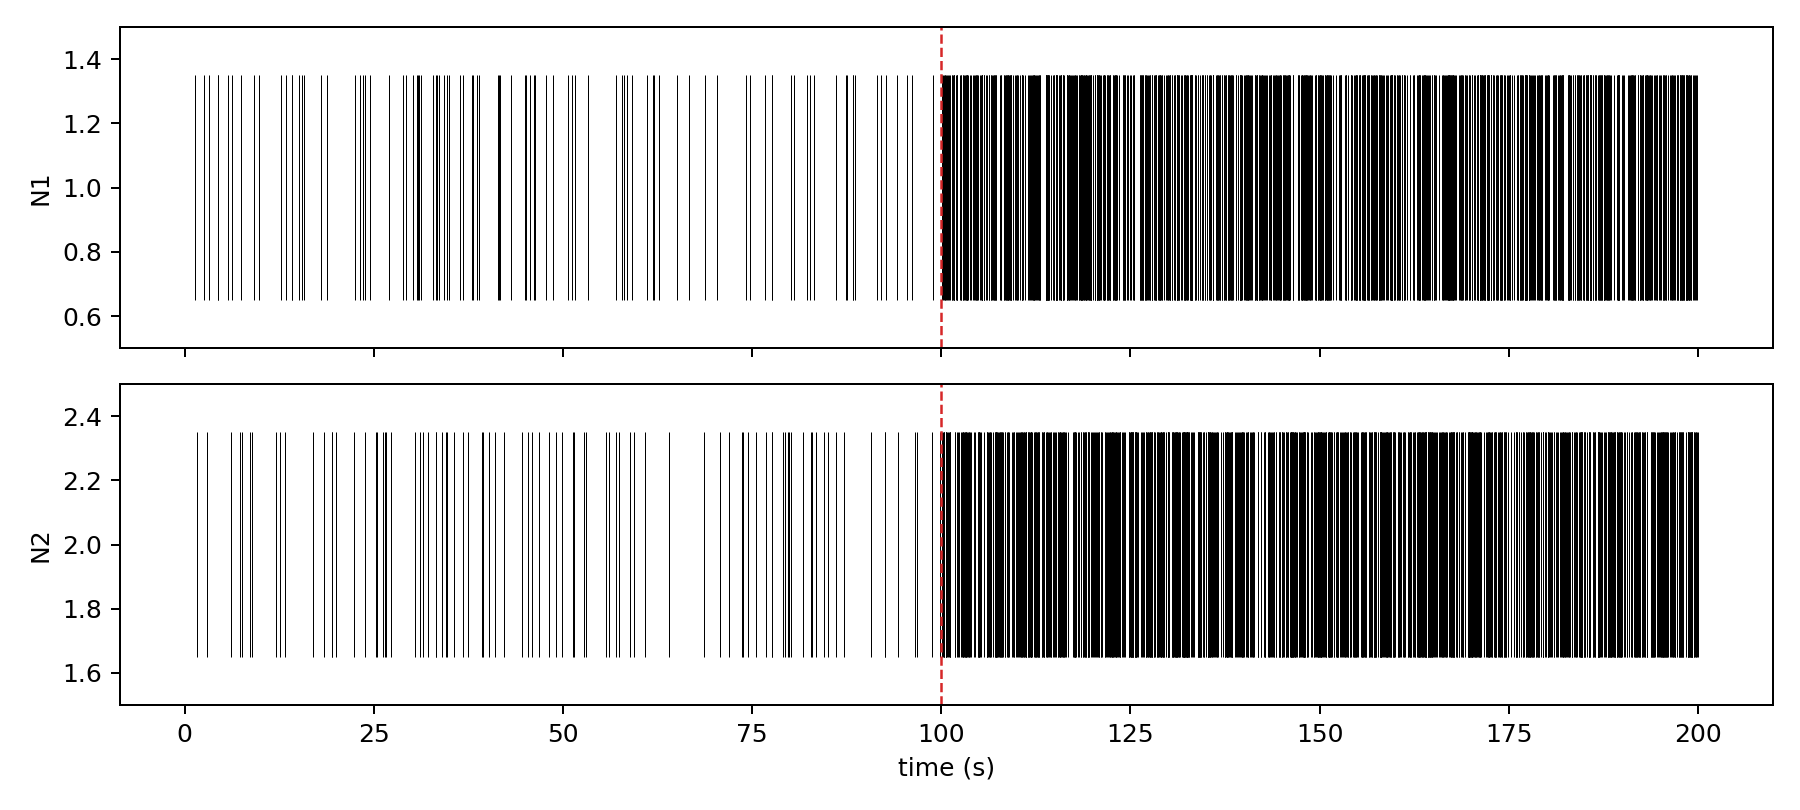

In [7]:
# SECTION 5: Run the constant-rate analysis
fig = _prepare_figure("results{1}.lambda.plot", figsize=(10.0, 4.5))
axs = fig.subplots(1, 2, sharey=True)
for idx, ax in enumerate(axs):
    fit = constant_results[idx]
    time_s, lambda_cols = _lambda_columns(fit)
    ax.plot(time_s, lambda_cols[:, 0], color="tab:blue", linewidth=1.25, label="Estimated λ(t)")
    ax.axhline(constant_case["lambda_hz"], color="tab:red", linestyle="--", linewidth=1.25, label="True λ")
    ax.set_title(f"Neuron {idx + 1}")
    ax.set_xlabel("time (s)")
    ax.grid(alpha=0.25)
axs[0].set_ylabel("rate (Hz)")
axs[1].legend(loc="best", frameon=False, fontsize=8)


In [8]:
# SECTION 6: Case #2: Piece-wise Constant Rate Poisson Process
# Next we compare a single-rate model against a two-epoch rate model.
piecewise_time = np.asarray(piecewise_case["time_s"], dtype=float)
piecewise_trains = list(piecewise_case["trains"])


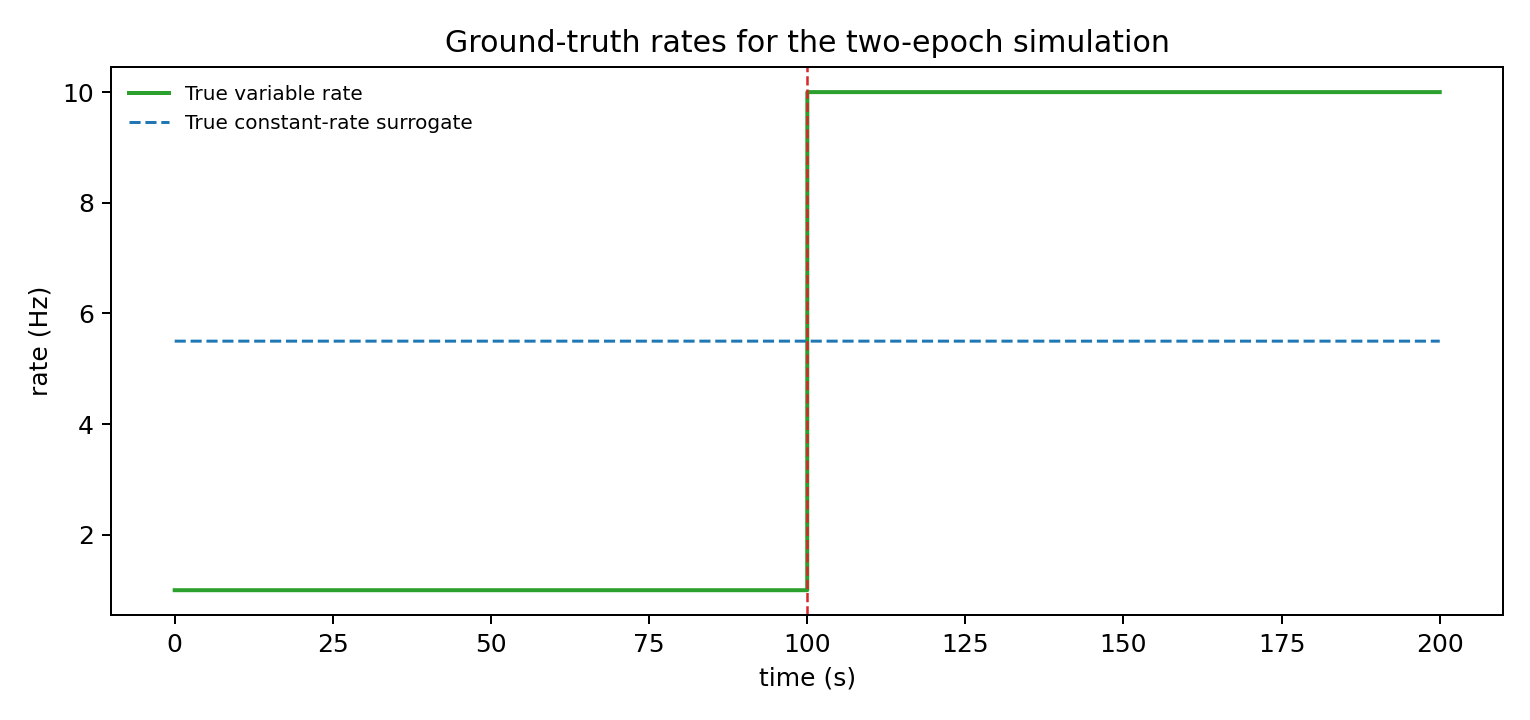

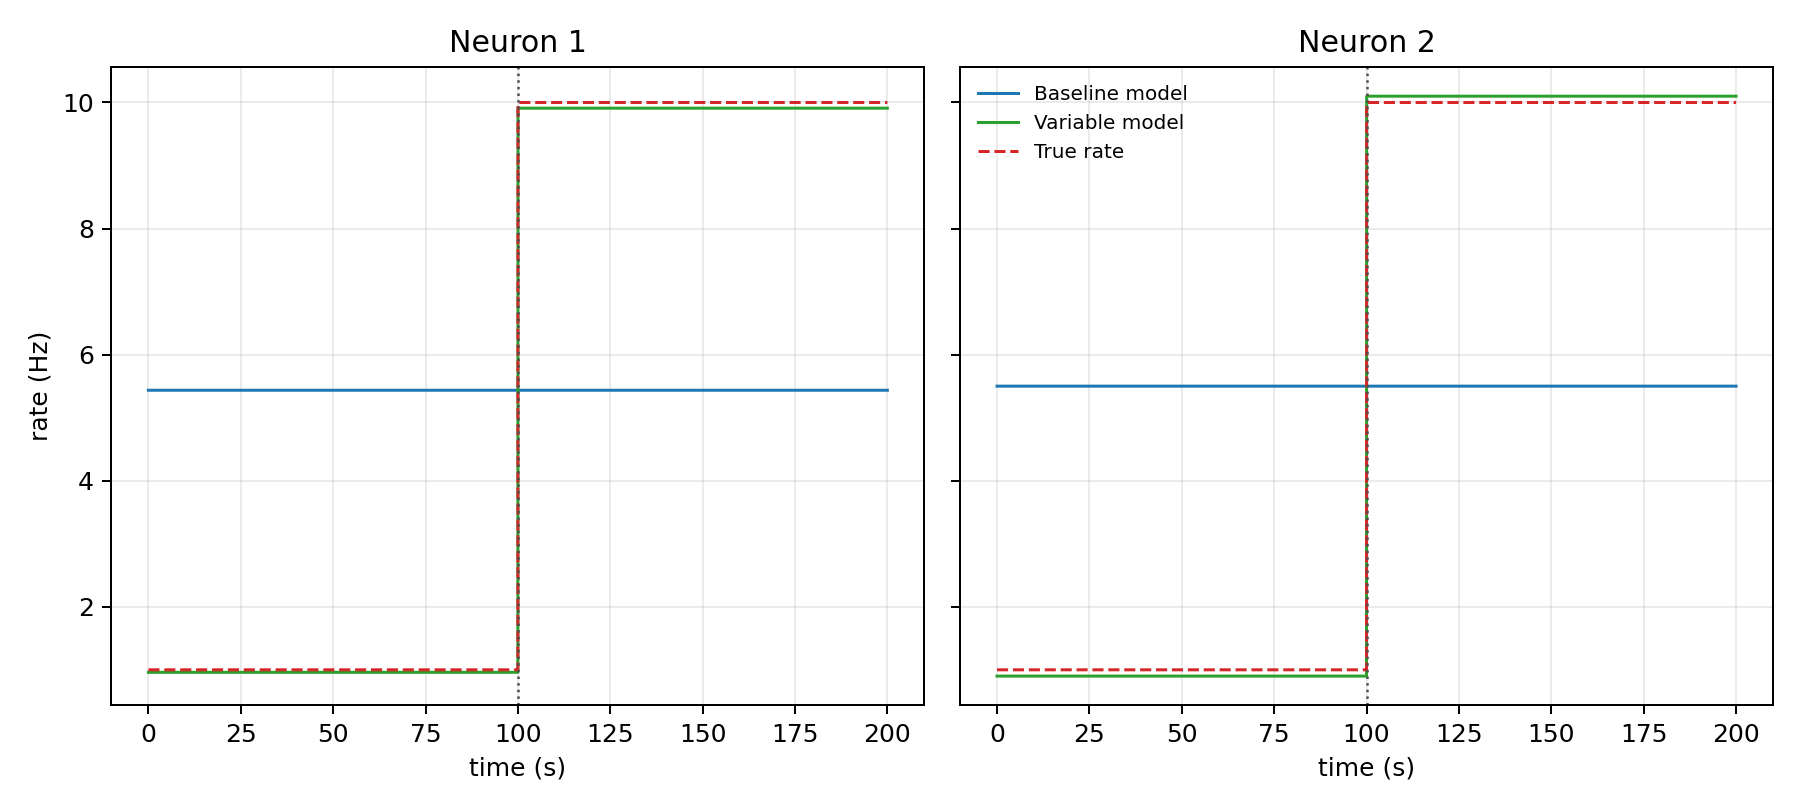

In [9]:
# SECTION 7: Generate the piecewise-rate spike trains
fig = _prepare_figure("plot(spikeTimes1, spikeTimes2)", figsize=(10.0, 4.5))
axs = fig.subplots(2, 1, sharex=True)
for row, train in enumerate(piecewise_trains, start=1):
    spikes = np.asarray(train.getSpikeTimes(), dtype=float)
    if spikes.size:
        axs[row - 1].vlines(spikes, row - 0.35, row + 0.35, color="k", linewidth=0.4)
    axs[row - 1].axvline(piecewise_case["edge_time_s"], color="tab:red", linestyle="--", linewidth=1.0)
    axs[row - 1].set_ylim(row - 0.5, row + 0.5)
    axs[row - 1].set_ylabel(f"N{row}")
axs[-1].set_xlabel("time (s)")

fig = _prepare_figure("plot(truePiecewiseRate)", figsize=(8.5, 4.0))
ax = fig.subplots(1, 1)
ax.plot(piecewise_time, np.where(piecewise_time <= piecewise_case["edge_time_s"], piecewise_case["lambda1_hz"], piecewise_case["lambda2_hz"]), color="tab:green", linewidth=1.6, label="True variable rate")
ax.plot(piecewise_time, np.full_like(piecewise_time, piecewise_case["lambda_const_hz"]), color="tab:blue", linewidth=1.2, linestyle="--", label="True constant-rate surrogate")
ax.axvline(piecewise_case["edge_time_s"], color="tab:red", linestyle="--", linewidth=1.0)
ax.set_title("Ground-truth rates for the two-epoch simulation")
ax.set_xlabel("time (s)")
ax.set_ylabel("rate (Hz)")
ax.legend(loc="best", frameon=False, fontsize=8)


In [10]:
# SECTION 8: Setup the piecewise-rate analysis
piecewise_results = Analysis.RunAnalysisForAllNeurons(piecewise_case["trial"], piecewise_case["cfg"], 0)


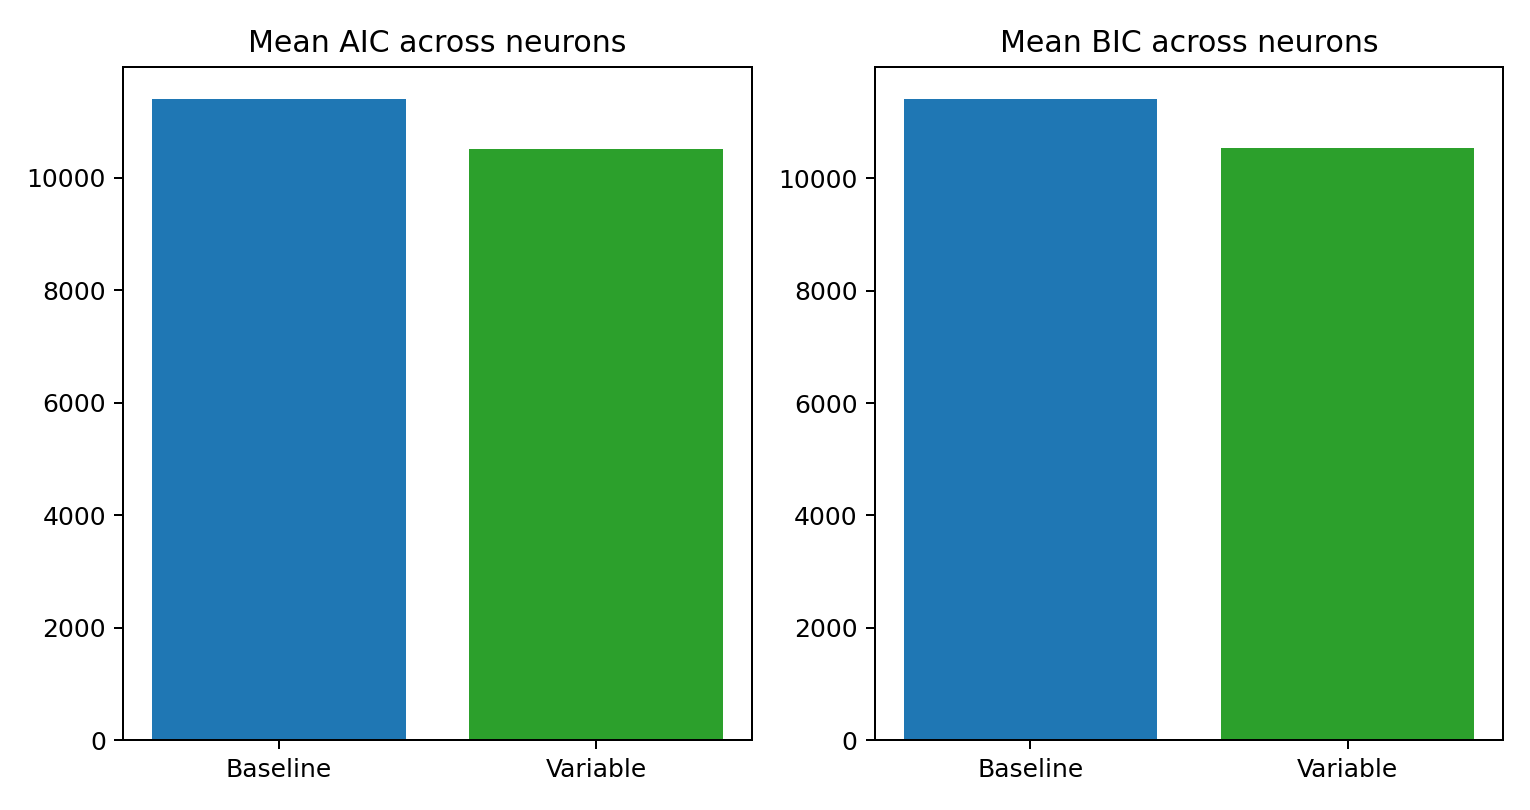

In [11]:
# SECTION 9: Run the piecewise-rate analysis
fig = _prepare_figure("results{1}.lambda.plot", figsize=(10.0, 4.5))
axs = fig.subplots(1, 2, sharey=True)
for idx, ax in enumerate(axs):
    fit = piecewise_results[idx]
    time_s, lambda_cols = _lambda_columns(fit)
    ax.plot(time_s, lambda_cols[:, 0], color="tab:blue", linewidth=1.2, label="Baseline model")
    ax.plot(time_s, lambda_cols[:, 1], color="tab:green", linewidth=1.2, label="Variable model")
    ax.plot(
        time_s,
        np.where(
            time_s <= piecewise_case["edge_time_s"],
            piecewise_case["lambda1_hz"],
            piecewise_case["lambda2_hz"],
        ),
        color="tab:red",
        linestyle="--",
        linewidth=1.2,
        label="True rate",
    )
    ax.axvline(piecewise_case["edge_time_s"], color="0.3", linestyle=":", linewidth=1.0)
    ax.set_title(f"Neuron {idx + 1}")
    ax.set_xlabel("time (s)")
    ax.grid(alpha=0.25)
axs[0].set_ylabel("rate (Hz)")
axs[1].legend(loc="best", frameon=False, fontsize=8)


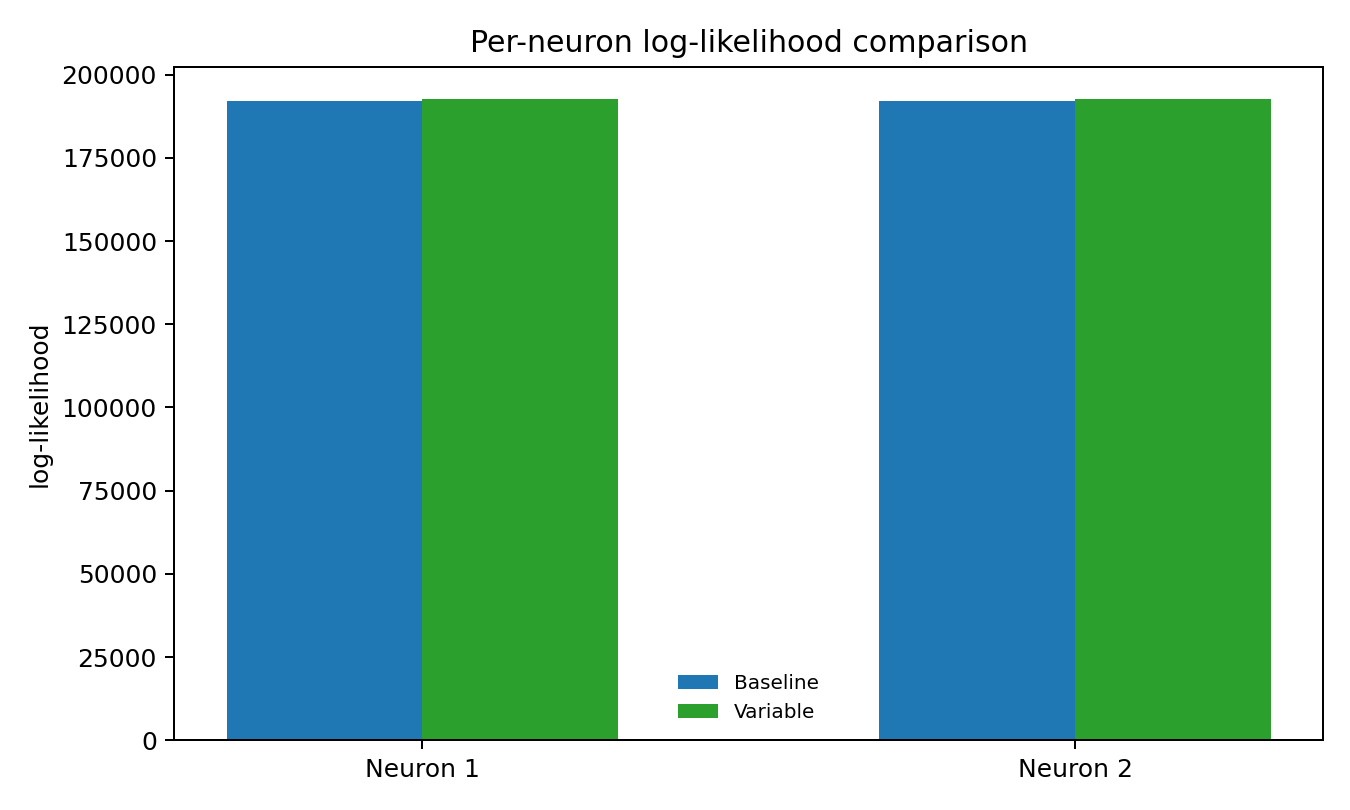

In [12]:
# SECTION 10: Compare the results across the two neurons
summary = FitResSummary(piecewise_results)
fig = _prepare_figure("Summary.plotSummary", figsize=(8.5, 4.5))
axs = fig.subplots(1, 2)
xloc = np.arange(len(summary.fitNames))
axs[0].bar(xloc, summary.meanAIC, color=["tab:blue", "tab:green"])
axs[0].set_xticks(xloc, summary.fitNames)
axs[0].set_title("Mean AIC across neurons")
axs[1].bar(xloc, summary.meanBIC, color=["tab:blue", "tab:green"])
axs[1].set_xticks(xloc, summary.fitNames)
axs[1].set_title("Mean BIC across neurons")

fig = _prepare_figure("Summary.getDifflogLL", figsize=(7.5, 4.5))
ax = fig.subplots(1, 1)
neuron_ids = np.arange(1, len(piecewise_results) + 1)
base_logll = np.asarray([fit.logLL[0] for fit in piecewise_results], dtype=float)
var_logll = np.asarray([fit.logLL[1] for fit in piecewise_results], dtype=float)
ax.bar(neuron_ids - 0.15, base_logll, width=0.3, color="tab:blue", label="Baseline")
ax.bar(neuron_ids + 0.15, var_logll, width=0.3, color="tab:green", label="Variable")
ax.set_xticks(neuron_ids, [f"Neuron {idx}" for idx in neuron_ids])
ax.set_ylabel("log-likelihood")
ax.set_title("Per-neuron log-likelihood comparison")
ax.legend(loc="best", frameon=False, fontsize=8)
__tracker.finalize()
